# Exp1

## Using glove-wiki-gigaword-50

In [1]:
import gensim.downloader as api
model = api.load('glove-wiki-gigaword-50')
similar_words = model.most_similar(['king', 'woman'], ['man'])
print('king - man + woman is closest to:', similar_words[0][0])

king - man + woman is closest to: queen


## Using word2vec-google-news-300

In [2]:
import gensim.downloader as api
model = api.load('word2vec-google-news-300')
similar_words = model.most_similar(['king', 'woman'], ['man'])
print('king - man + woman is closest to:', similar_words[0][0])

king - man + woman is closest to: queen


# Exp2

## PCA

5 similar words to king: [('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721)]


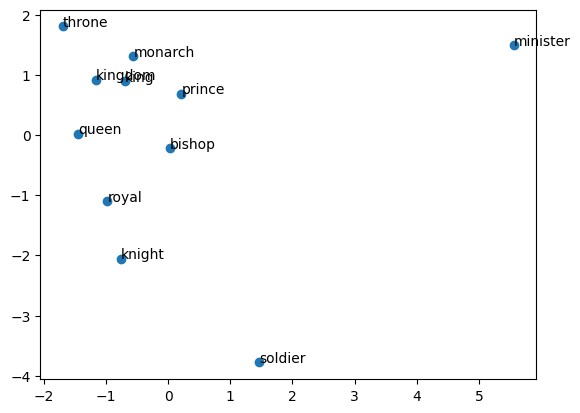

In [3]:
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model = api.load('glove-wiki-gigaword-50')

words = [
    'queen', 'king', 'throne', 'monarch',
    'kingdom', 'prince', 'minister', 'knight',
    'bishop', 'royal', 'soldier',
]
vectors = [model[word] for word in words]
vectors = PCA(2).fit_transform(vectors)

print("5 similar words to king:", model.most_similar('king', topn=5))

plt.scatter(vectors[:, 0], vectors[:, 1])
for i, word in enumerate(words):
    plt.text(vectors[i, 0], vectors[i, 1], word)
plt.show()

## TSNE

5 similar words to king: [('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721)]


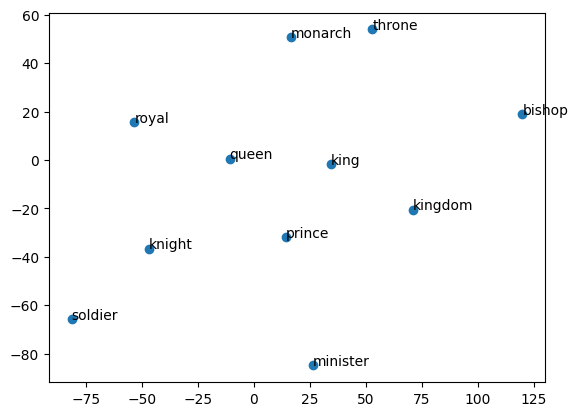

In [4]:
import gensim.downloader as api
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

model = api.load('glove-wiki-gigaword-50')

words = [
    'queen', 'king', 'throne', 'monarch',
    'kingdom', 'prince', 'minister', 'knight',
    'bishop', 'royal', 'soldier',
]
vectors = np.array([model[word] for word in words])
vectors = TSNE(2, perplexity=5).fit_transform(vectors)

print("5 similar words to king:", model.most_similar('king', topn=5))

plt.scatter(vectors[:, 0], vectors[:, 1])
for i, word in enumerate(words):
    plt.text(vectors[i, 0], vectors[i, 1], word)
plt.show()

# Exp3

In [5]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

sentences = [
    "This is a legal document about contracts.",
    "The court will review this legal case.",
    "Medical professionals require specific training.",
    "This is a medical report of a patient.",
]

sentences = [simple_preprocess(sentence) for sentence in sentences]
model = Word2Vec(sentences, min_count=1).wv
print(model.most_similar('legal', topn=5))

[('specific', 0.19910520315170288), ('case', 0.17275597155094147), ('patient', 0.17022423446178436), ('document', 0.1528286635875702), ('report', 0.14595209062099457)]


# Exp4

In [6]:
import gensim.downloader as api
from transformers import pipeline

word_vectors = api.load('glove-wiki-gigaword-50')
generator = pipeline('text-generation', 'gpt2')

prompt = "Who is king"
print("Original prompt:", prompt)

similar_word = word_vectors.most_similar("king")[0][0]
enriched_prompt = prompt.replace("king", similar_word)
print("Enriched prompt:", enriched_prompt)

output = generator(prompt, max_length=50)[0]['generated_text']
enriched_output = generator(enriched_prompt, max_length=50)[0]['generated_text']

print("Original Response:\n", output)
print("Enriched Response:\n", enriched_output)

print("Length Comparison:", len(output), "vs", len(enriched_output))
print("Count of sentences:", output.count('.'), "vs", enriched_output.count('.'))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Original prompt: Who is king
Enriched prompt: Who is prince


Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original Response:
 Who is king is not king. It is not his will; it is not his power. It is not his desire. It is not his desire to be king. It is not his desire to be king to be king. It is not his desire to be king to be king. It is not his desire to be king to be king. It is not his desire to be king to be king.

But I say unto you, If it be not his will, it is not his will; it is not his power. It is not his desire. It is not his desire to be king to be king. It is not his desire to be king to be king.

Therefore let it be your will unto him who is king to be king.

And it be your will unto him who is king to be king.

Then let it be your will unto him who is king to be king.

And it be your will unto him who is king to be king.

And it be your will unto him who is king to be king.

And it be your will unto him who is king to be king.

And it be your will unto him who is king to be king.

Therefore let it be
Enriched Response:
 Who is prince of the forest?

Are you prince of the fo

# Exp5

In [7]:
import gensim.downloader as api

word_vectors = api.load('glove-wiki-gigaword-50')

seed = input("Enter seed word:")

similar_words = [word for word, score in word_vectors.most_similar(seed)]

paragraph = f"""
The {seed} was known for its connection with {similar_words[0]} and {similar_words[1]}.
People often relate this to {similar_words[2]} and {similar_words[3]}.
In many stories, {similar_words[4]} played important role alongside the {seed}.
"""

print("Generated paragraph:\n", paragraph)

Enter seed word: travel


Generated paragraph:
 
The travel was known for its connection with trips and travelers.
People often relate this to traveling and destinations.
In many stories, flights played important role alongside the travel.



# Exp6

In [8]:
from transformers import pipeline

analyzer = pipeline("sentiment-analysis")

reviews = [
    "Amazing!! Great product!",
    "Very disappointed with this product",
    "Terrible experiance",
    "Gets the job done",
]

for review in reviews:
    result = analyzer(review)[0]
    print(f"{review} -> {result['label']} ({result['score']:.4f})")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Amazing!! Great product! -> POSITIVE (0.9999)
Very disappointed with this product -> NEGATIVE (0.9998)
Terrible experiance -> NEGATIVE (0.9987)
Gets the job done -> POSITIVE (0.9995)


# Exp7

In [9]:
from transformers import pipeline

# summarizer = pipeline('summarization', facebook/bart-large-cnn')
summarizer = pipeline('text-generation', 'gpt2')

text = """
Summarize this:
Artificial Intelligence (AI) is a rapidly evolving field focused on creating intelligent machines.
It has impacted industries like healthcare, finance, and education. AI applications include chatbots,
self-driving cars, and recommendation systems. However, it also raises ethical concerns like bias
and job displacement.
"""

summary = summarizer(text, max_length=25)[0]['generated_text']
# print("Summary:", summary[0]['summary_text'])
print("Summary:", summary)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=25) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summary: 
Summarize this:
Artificial Intelligence (AI) is a rapidly evolving field focused on creating intelligent machines.
It has impacted industries like healthcare, finance, and education. AI applications include chatbots,
self-driving cars, and recommendation systems. However, it also raises ethical concerns like bias
and job displacement.

The question that comes to mind is: what does this mean for our future?

For my part, I understand the importance of AI. I believe that AI is the next big thing for humankind.

I believe that our future is a bright future for humanity.

I believe that AI is the future of the digital world.

I believe that computers will never be just a means to an end. They will become the means to an end in a much simpler and more secure manner. And when you use computer technology, you will never be left behind.

Of course, that's a big thing. But I'm not sure that the future of AI is that bright.

I'd love to say this:

If you're an AI enthusiast, you probab

# Exp9

In [10]:
from pydantic import BaseModel
import json

class InstitutionDetails(BaseModel):
    founder: str | None
    founded: str | None
    branches: list[str] | None
    number_of_employees: int | None
    summary: str | None

    def __str__(self):
        out = "founder: " + self.founder + "\n"
        out += "founded: " + self.founded + "\n"
        out += "branches: " + (", ".join(branch for branch in self.branches) or "None") + "\n"
        out += "number_of_employees: " + (str(self.number_of_employees) or "None") + "\n"
        out += "summary: " + self.summary
        return out

data = json.load(open("institutions.json"))

name = input("Enter institution name:").strip()
if name not in data:
    print("Institution details not found!")
else:
    print("Details:"); print(InstitutionDetails(**data[name]))

Enter institution name: MIT


Details:
founder: Someone
founded: Someday
branches: A, B, C
number_of_employees: 50
summary: A long summary
